In [62]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal,Annotated
import operator
from langchain_core.messages import SystemMessage,HumanMessage
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from langchain_core.output_parsers import PydanticOutputParser
from dotenv import load_dotenv


In [63]:
load_dotenv()

llm=HuggingFaceEndpoint(
    repo_id='Qwen/Qwen2.5-7B-Instruct',
    task='text-generation'

)


In [64]:
model_generate=ChatHuggingFace(llm=llm)
model_evaluate=ChatHuggingFace(llm=llm)
model_optimize=ChatHuggingFace(llm=llm)

In [65]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")
parser=PydanticOutputParser(pydantic_object=TweetEvaluation)

In [66]:
class TweetState(TypedDict):

    topic:str
    tweet:str
    evaluation:Literal['approved','needs_improvement']
    feedback:str
    iteration:int
    max_iteration:int

In [67]:
def generate_tweet(state:TweetState):

    prompt=message=[
        SystemMessage(content='you are funny and clever Twitter/X influencer.'),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    response=model_generate.invoke(prompt)
    return {'tweet':response.content}
    

In [68]:
def evaluate_tweet(state:TweetState):

    prompt=message=[
        SystemMessage(content='You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format.'),
        HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
{parser.get_format_instructions()}
""")
    ]

    result=model_evaluate.invoke(prompt)
    response=parser.parse(result.content)
    return {'evaluation':response.evaluation,'feedback':response.feedback}

In [69]:
def optimize_tweet(state:TweetState):

    prompt=message=[
        SystemMessage(content='You punch up tweets for virality and humor based on given feedback.'),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response=model_optimize.invoke(prompt)
    iteration=state['iteration']+1
    return {'tweet':response.content, 'iteration':iteration}

In [70]:
def evaluation(state:TweetState):

    if state['evaluation']=='approved' or state['iteration']>= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

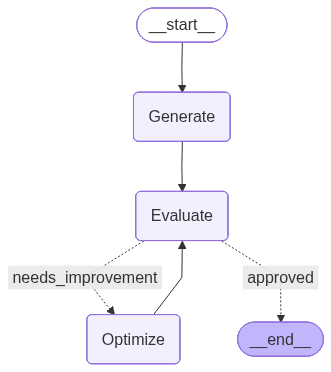

In [71]:
graph=StateGraph(TweetState)

graph.add_node('Generate',generate_tweet)
graph.add_node('Evaluate',evaluate_tweet)
graph.add_node('Optimize',optimize_tweet)

graph.add_edge(START,'Generate')
graph.add_edge('Generate','Evaluate')
graph.add_conditional_edges('Evaluate',evaluation,{'approved':END,'needs_improvement':'Optimize'})
graph.add_edge('Optimize','Evaluate')

workflow=graph.compile()
workflow


In [72]:
initial_state={
    'topic':'Unemployment',
    'iteration':1,
    'max_iteration':3
}

In [ ]:
result=workflow.invoke(initial_state)


In [78]:
print(result['topic'])
print(result['tweet'])

Unemployment
Just hit the job market hard with my resume 📄 and got this response: "Thanks, but we're hiring plants instead." 🌱 #Unemployment #JobSeekerJourney
